In [ ]:
# Mini Wheelbot Statistical Analysis

## Drive-Wheel Angular Velocity vs Robot Pitch

"""This notebook provides the visual and statistical exploration of
the Mini Wheelbot dataset. """

### Objective

"""To investigate the relationship between drive-wheel angular
velocity and robot pitch angle."""

### X

# Drive-wheel angular velocity

### Y

# Robot pitch angle

### Model

# Simple Linear Regression

SyntaxError: invalid syntax (4188471830.py, line 5)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

In [ ]:
file_path = "../data/velocity_pitch/0.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
print("Dataset shape:", df.shape)

df.head()

Dataset shape: (14814, 57)


,_time,/gyro0/x,/gyro0/y,/gyro0/z,/gyro1/x,/gyro1/y,/gyro1/z,/gyro2/x,/gyro2/y,/gyro2/z,...,/setpoint/balancing_wheel_angle,/setpoint/balancing_wheel_angular_velocity,/vicon_position/x,/vicon_position/y,/vicon_position/z,/vicon_orientation_wxyz/w,/vicon_orientation_wxyz/x,/vicon_orientation_wxyz/y,/vicon_orientation_wxyz/z,battery/voltage
0,0.000000,0.003458,-0.011970,0.003458,-0.001596,-0.014896,0.002128,0.003724,-0.001330,0.004256,...,0,0,664.898,2747.41,109.2560,0.814900,0.120319,0.347387,0.448089,0.0
1,0.001012,-0.000798,-0.007714,0.001064,-0.000798,-0.011970,0.007448,-0.008512,-0.004788,0.007714,...,0,0,662.042,2735.90,107.5250,0.787976,0.132068,0.313430,0.513239,0.0
2,0.002016,-0.002128,-0.007980,-0.001064,-0.000266,-0.003990,0.006916,-0.010374,-0.002128,0.009044,...,0,0,762.978,2890.98,88.3967,0.603634,0.307942,-0.337534,-0.653352,0.0
3,0.003030,-0.000798,-0.008778,-0.003458,-0.002926,0.000266,0.005586,-0.004256,-0.000532,0.006384,...,0,0,762.969,2891.01,88.4118,0.603629,0.308041,-0.337758,-0.653194,0.0
4,0.004016,-0.000532,-0.007714,-0.002128,-0.006916,-0.004256,0.005852,0.003990,0.003990,-0.001862,...,0,0,762.976,2890.99,88.3908,0.603694,0.308022,-0.337496,-0.653278,0.0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14814 entries, 0 to 14813
Data columns (total 57 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   _time                                       14814 non-null  float64
 1   /gyro0/x                                    14814 non-null  float64
 2   /gyro0/y                                    14814 non-null  float64
 3   /gyro0/z                                    14814 non-null  float64
 4   /gyro1/x                                    14814 non-null  float64
 5   /gyro1/y                                    14814 non-null  float64
 6   /gyro1/z                                    14814 non-null  float64
 7   /gyro2/x                                    14814 non-null  float64
 8   /gyro2/y                                    14814 non-null  float64
 9   /gyro2/z                                    14814 non-null  float64
 10  /gyro3/x             

In [ ]:
df.describe()

,_time,/gyro0/x,/gyro0/y,/gyro0/z,/gyro1/x,/gyro1/y,/gyro1/z,/gyro2/x,/gyro2/y,/gyro2/z,...,/setpoint/balancing_wheel_angle,/setpoint/balancing_wheel_angular_velocity,/vicon_position/x,/vicon_position/y,/vicon_position/z,/vicon_orientation_wxyz/w,/vicon_orientation_wxyz/x,/vicon_orientation_wxyz/y,/vicon_orientation_wxyz/z,battery/voltage
count,14814.000000,14814.000000,14814.000000,14814.000000,14814.000000,14814.000000,14814.000000,14814.000000,14814.000000,14814.000000,...,14814.0,14814.0,14814.000000,14814.000000,14814.000000,14814.000000,14814.000000,14814.000000,14814.000000,14814.000000
mean,7.406507,-0.124931,-0.016353,0.034847,-0.131563,-0.000832,0.034329,-0.124737,0.003435,0.037046,...,0.0,0.0,850.041014,2782.729920,75.769691,0.734331,0.058553,-0.072016,-0.594632,20.402360
std,4.276573,0.733732,0.213290,0.201634,0.728507,0.216167,0.199033,0.724487,0.212734,0.202781,...,0.0,0.0,66.931149,113.766147,24.031078,0.095707,0.214486,0.196328,0.069673,5.559237
min,0.000000,-4.621480,-2.747780,-3.431930,-4.589560,-2.613180,-3.447360,-4.582120,-2.716390,-3.356650,...,0.0,0.0,662.042000,2637.850000,12.012800,0.602784,-0.386785,-0.339344,-0.717863,0.000000
25%,3.703267,-0.063574,-0.023940,-0.003458,-0.074680,-0.015428,-0.002660,-0.058454,-0.007448,-0.002660,...,0.0,0.0,762.971000,2665.510000,81.851300,0.603669,0.006800,-0.337523,-0.653265,21.770000
50%,7.406510,0.001862,-0.007714,0.002926,-0.005054,-0.003990,0.004256,0.001862,0.002660,0.004522,...,0.0,0.0,859.766000,2815.720000,83.598750,0.764004,0.018918,0.010351,-0.611258,22.000000
75%,11.109750,0.052934,0.005852,0.047880,0.043624,0.027398,0.045220,0.048412,0.023408,0.050540,...,0.0,0.0,899.804000,2891.000000,88.407400,0.811955,0.307931,0.023666,-0.537845,22.010000
max,14.813000,2.053790,0.975422,1.979570,1.906160,0.952546,1.963350,1.937540,0.944832,1.975050,...,0.0,0.0,953.138000,2919.290000,109.256000,0.856105,0.309321,0.347387,0.513239,22.030000


In [ ]:
velocity_column = "/dq_DR/drive_wheel"
pitch_column = "/q_yrp/pitch"

analysis_df = df[
    [velocity_column, pitch_column]
].dropna()

X = analysis_df[[velocity_column]]
y = analysis_df[pitch_column]

print("Analysis samples:", len(analysis_df))

Analysis samples: 14814


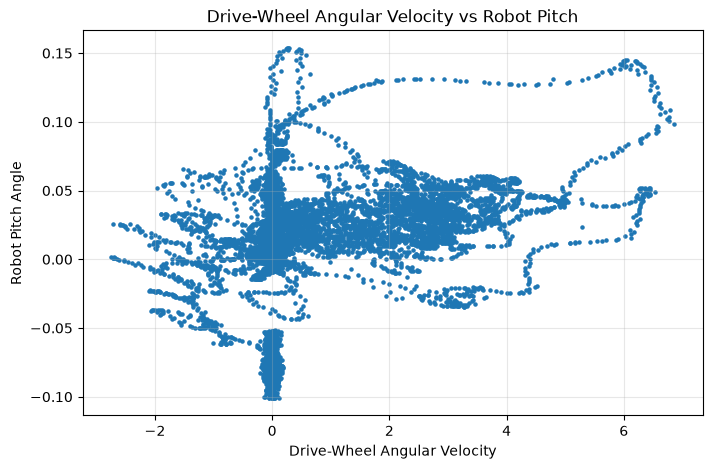

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X[velocity_column],
    y,
    s=5
)

plt.xlabel("Drive-Wheel Angular Velocity")
plt.ylabel("Robot Pitch Angle")

plt.title(
    "Drive-Wheel Angular Velocity vs Robot Pitch"
)

plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
plt.savefig(
    "../results/Drive-Wheel Augular Velocity vs Robot Pitch.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
correlation = X[
    velocity_column
].corr(y)

print(
    f"Correlation: {correlation:.6f}"
)

Correlation: 0.394541


In [ ]:
split_index = int(
    len(analysis_df) * 0.80
)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 11851
Testing samples: 2963


In [ ]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

intercept = model.intercept_
coefficient = model.coef_[0]

print(
    f"Pitch = {intercept:.6f} + "
    f"({coefficient:.6f} × Drive-Wheel Angular Velocity)"
)

Pitch = -0.033062 + (0.020612 × Drive-Wheel Angular Velocity)


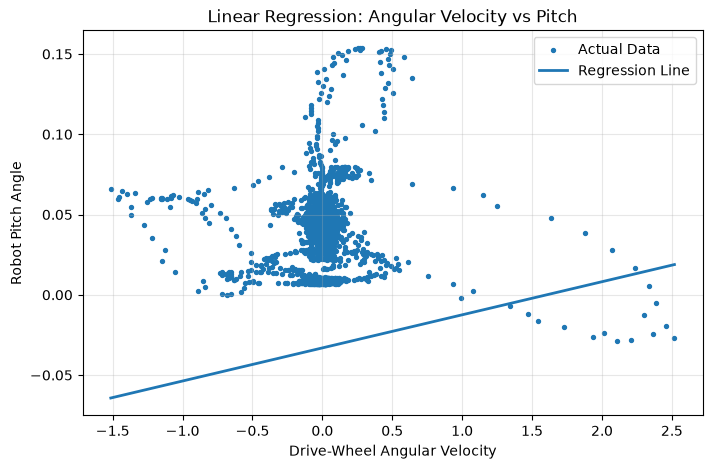

In [ ]:
y_pred = model.predict(X_test)

sort_index = np.argsort(
    X_test[velocity_column].values
)

plt.figure(figsize=(8, 5))

plt.scatter(
    X_test[velocity_column],
    y_test,
    s=8,
    label="Actual Data"
)

plt.plot(
    X_test[velocity_column].values[sort_index],
    y_pred[sort_index],
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Drive-Wheel Angular Velocity")
plt.ylabel("Robot Pitch Angle")

plt.title(
    "Linear Regression: Angular Velocity vs Pitch"
)

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
plt.savefig(
    "../results/Linear Regression.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

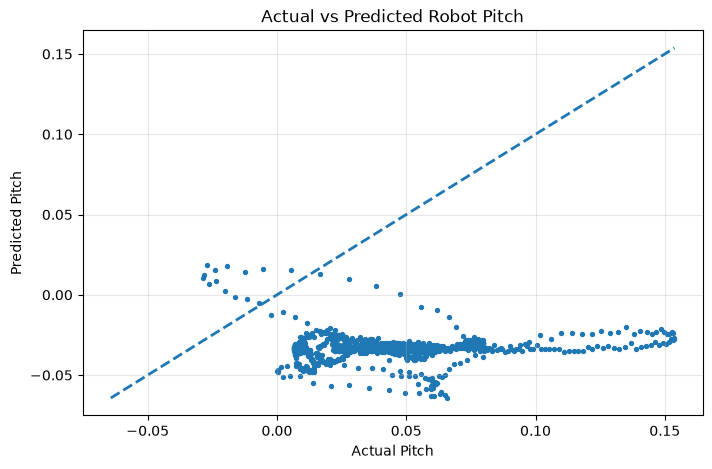

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred,
    s=8
)

min_value = min(
    y_test.min(),
    y_pred.min()
)

max_value = max(
    y_test.max(),
    y_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Pitch")
plt.ylabel("Predicted Pitch")

plt.title(
    "Actual vs Predicted Robot Pitch"
)

plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
plt.savefig(
    "../results/actual_vs_prediction.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

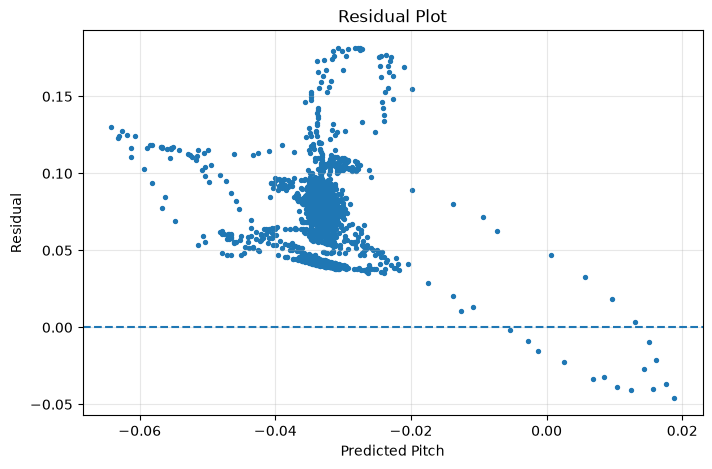

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    s=8
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Pitch")
plt.ylabel("Residual")

plt.title(
    "Residual Plot"
)

plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
plt.savefig(
    "../results/residual_plot.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [ ]:
r2 = r2_score(
    y_test,
    y_pred
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

results = pd.DataFrame({
    "Metric": [
        "Correlation",
        "R²",
        "MAE",
        "RMSE"
    ],

    "Value": [
        correlation,
        r2,
        mae,
        rmse
    ]
})

results

,Metric,Value
0,Correlation,0.394541
1,R²,-7.676471
2,MAE,0.068338
3,RMSE,0.072651


In [ ]:
# Results and Interpretation

### Correlation

"""The correlation coefficient describes the direction and strength of
the linear association between drive-wheel angular velocity and
robot pitch.

### Regression Coefficient

The regression coefficient represents the estimated change in pitch
associated with a one-unit change in drive-wheel angular velocity
within the analyzed data.

### R²

R² indicates the proportion of variation in the test-set pitch that
is explained by the linear regression model.

### MAE

MAE represents the average absolute prediction error.

### RMSE

RMSE represents prediction error while giving greater weight to
larger errors.

### Important Note

These results describe statistical association and model
performance. They do not by themselves prove that changes in
wheel angular velocity cause changes in robot pitch."""